# 练手项目：同一份数据，回归 + 分类全流程

这个 notebook 是 ML 练手项目，所有数据来自 arXiv:2608.05531 的
REGALADE–GSWLC-2 匹配样本（与 `ML_REPRODUCTION.ipynb` 同一份数据、同一套清洗和切分）。

我们要做两件之前没做过的事：

**Part 1（回归，模型动物园）**：同一个任务"用 7 个特征预测 logSFR"，
换 4 种不同模型的对比——线性回归、随机森林、CatBoost、小型神经网络。
核心问题：*换一种模型，RMSE 能差多少？为什么？*

**Part 2（分类，新技能）**：把问题从"回归一个数"改成"分成两类"——
恒星形成星系 vs 静止星系。核心问题：*"分类准不准"该用什么指标？
类别不平衡时 accuracy 会怎样骗人？*

流程：

$$
\text{读表} \to \text{清洗} \to \text{7 特征} \to \text{2/3–1/3 切分} \to \text{4 模型回归对比} \to \text{3 模型分类对比} \to \text{特征重要性}
$$

> 与作者基线一致：`random_seed=42`，`test_size=1/3`，训练集 223,376 行，
> blind 111,688 行。所有指标都报 **train-validation 和 blind 两套**——
> 只有 blind 可信，train 只用来判断是否过拟合。


In [1]:
# 0. 环境与路径（与 ML_REPRODUCTION.ipynb 相同）
from pathlib import Path
import json
import os
import sys
import time

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

HERE = Path.cwd().resolve()
if HERE.name != "arxiv_2608_05531":
    raise RuntimeError("请从 scripts/experiments/arxiv_2608_05531 启动 notebook")

REPO = HERE.parents[2]
DATA_DIR = (
    REPO
    / "external_data/literature_sources/arxiv_2608_05531/zenodo_20695048"
)
OUT_DIR = REPO / "outputs/reproductions/arxiv_2608_05531/ml_practice"
OUT_DIR.mkdir(parents=True, exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(OUT_DIR / ".matplotlib")

np.random.seed(42)
print("sklearn:", sklearn.__version__)


sklearn: 1.9.0


In [2]:
# 1. 读入、清洗、构造特征、切分（与作者基线完全一致）
train_raw = pd.read_csv(DATA_DIR / "Model_training.csv", dtype={"ObjID": "string"})
numeric_cols = train_raw.select_dtypes(include="number").columns
train_raw[numeric_cols] = train_raw[numeric_cols].replace(0.0, np.nan)
train_raw = train_raw.replace([np.inf, -np.inf], np.nan).dropna(subset=["logSFR"])

train_raw["g-r"] = train_raw["gmag"] - train_raw["rmag"]
train_raw["r-z"] = train_raw["rmag"] - train_raw["zmag"]
train_raw["z-W1"] = train_raw["zmag"] - train_raw["W1mag"]
train_raw["W1-W2"] = train_raw["W1mag"] - train_raw["W2mag"]

FEATURES = ["g-r", "r-z", "z-W1", "W1-W2", "redshift", "gmag", "logM"]
TARGET = "logSFR"

from sklearn.model_selection import train_test_split
train_val, blind = train_test_split(
    train_raw, test_size=1 / 3, random_state=42, shuffle=True
)
Xtv, ytv = train_val[FEATURES].to_numpy(), train_val[TARGET].to_numpy()
Xbl, ybl = blind[FEATURES].to_numpy(), blind[TARGET].to_numpy()
result_pool = {}  # 存每个模型的 (train, blind, time)
print(f"train-validation: {len(train_val):,}    blind: {len(blind):,}")
print(f"带缺失特征的 train-val 行: {np.isnan(Xtv).any(axis=1).sum():,}"
      f"   blind 行: {np.isnan(Xbl).any(axis=1).sum():,}")


train-validation: 223,376    blind: 111,688
带缺失特征的 train-val 行: 216   blind 行: 128


## Part 1：回归——同一个任务，4 种模型

评价量与作者基线一致：

$$
\mathrm{RMSE}=\sqrt{\tfrac1m\sum\Delta S^2},\quad
\mathrm{bias}=\overline{\Delta S},\quad
\sigma=\mathrm{std}(\Delta S),\quad
\eta=\frac{N(|\Delta S|>3\sigma)}{m}
$$

四个模型的"性格"各不相同，预测前先想清楚它们各会怎样：

| 模型 | 一句话描述 | 对缺失值 | 需要的预处理 |
|---|---|---|---|
| 线性回归 | 最小二乘直线，最简单 | 会报错 | **必须**填缺失 + 缩放到同量级 |
| RandomForest | 很多棵随机树取平均 | 可以 | 一般不用 |
| CatBoost | 1200 棵对称树接力（作者基线） | 原生支持 | 不用 |
| MLP | 小型神经网络 | 会报错 | **必须**缩放特征 |


In [3]:
# 2. 评价函数（与作者基线相同，再补一个 R2）
def evaluate(reference, prediction):
    residual = prediction - reference
    sigma = np.std(residual)
    from sklearn.metrics import r2_score
    return {
        "r2": r2_score(reference, prediction),
        "rmse": float(np.sqrt(np.mean(residual**2))),
        "bias": float(np.mean(residual)),
        "sigma": float(sigma),
        "eta": float(np.mean(np.abs(residual) > 3 * sigma)),
    }

# 训练时填缺失的策略：线性/MLP 需要。用简单的中位数填充，
# 树模型不填也能跑——这本身就是不同模型的"性格"。
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median").fit(Xtv)
Xtv_filled = imputer.transform(Xtv)
Xbl_filled = imputer.transform(Xbl)
print("中位数填充完成：train-val 缺失", np.isnan(Xtv).sum(),
      "->", np.isnan(Xtv_filled).sum())


中位数填充完成：train-val 缺失 321 -> 0


In [4]:
# 3. 模型 1：线性回归（你本科就会的 lstsq 的 sklearn 版本）
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# 线性回归对特征尺度敏感：先标准化到 均值0 方差1
scaler = StandardScaler().fit(Xtv_filled)
lr = LinearRegression()
t0 = time.perf_counter()
lr.fit(scaler.transform(Xtv_filled), ytv)
t_lr = time.perf_counter() - t0

pred_train = lr.predict(scaler.transform(Xtv_filled))
pred_blind = lr.predict(scaler.transform(Xbl_filled))
result_pool["Linear"] = {"train": pred_train, "blind": pred_blind,
                         "time": t_lr}
print(f"线性回归 用时 {t_lr:.2f}s")
print("  train:", evaluate(ytv, pred_train))
print("  blind:", evaluate(ybl, pred_blind))
print("  学到的系数(标准化后):",
      dict(zip(FEATURES, np.round(lr.coef_, 3))))


线性回归 用时 0.06s
  train: {'r2': 0.5629176175714634, 'rmse': 0.41562225103173067, 'bias': 2.0421550943610072e-17, 'sigma': 0.41562225103173067, 'eta': 0.02476094119332426}
  blind: {'r2': 0.5637561225150045, 'rmse': 0.412610273868301, 'bias': -0.002304052106113208, 'sigma': 0.41260384080321727, 'eta': 0.024971348757252345}
  学到的系数(标准化后): {'g-r': np.float64(-0.771), 'r-z': np.float64(0.298), 'z-W1': np.float64(0.065), 'W1-W2': np.float64(0.074), 'redshift': np.float64(0.335), 'gmag': np.float64(-0.025), 'logM': np.float64(0.217)}


In [5]:
# 4. 模型 2：RandomForest（很多棵随机树取平均）
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200, max_depth=None, random_state=42, n_jobs=-1
)
t0 = time.perf_counter()
rf.fit(Xtv_filled, ytv)  # 树模型不需要缩放
t_rf = time.perf_counter() - t0

pred_train = rf.predict(Xtv_filled)
pred_blind = rf.predict(Xbl_filled)
result_pool["RandomForest"] = {"train": pred_train, "blind": pred_blind,
                               "time": t_rf}
print(f"RandomForest 用时 {t_rf:.2f}s")
print("  train:", evaluate(ytv, pred_train))
print("  blind:", evaluate(ybl, pred_blind))


RandomForest 用时 16.59s
  train: {'r2': 0.965918111466735, 'rmse': 0.1160590376806878, 'bias': -0.002139304267244467, 'sigma': 0.11603931921818338, 'eta': 0.022791168254423035}
  blind: {'r2': 0.7488940015715767, 'rmse': 0.31304293647831327, 'bias': -0.007803966182580045, 'sigma': 0.3129456473427717, 'eta': 0.022500179070267173}


In [6]:
# 5. 模型 3：CatBoost（作者基线，1200 树）
from catboost import CatBoostRegressor

cb = CatBoostRegressor(
    iterations=1200, depth=10, learning_rate=0.05,
    loss_function="RMSE", random_seed=42,
    verbose=False, allow_writing_files=False,
)
t0 = time.perf_counter()
cb.fit(Xtv, ytv)  # CatBoost 原生处理 NaN，直接喂原始 X
t_cb = time.perf_counter() - t0

pred_train = cb.predict(Xtv)
pred_blind = cb.predict(Xbl)
result_pool["CatBoost"] = {"train": pred_train, "blind": pred_blind,
                           "time": t_cb}
print(f"CatBoost 用时 {t_cb:.2f}s")
print("  train:", evaluate(ytv, pred_train))
print("  blind:", evaluate(ybl, pred_blind))


CatBoost 用时 30.60s
  train: {'r2': 0.8040267217283947, 'rmse': 0.2783015134983797, 'bias': 4.617264936681132e-06, 'sigma': 0.2783015134600775, 'eta': 0.021680932597951435}
  blind: {'r2': 0.7595949920649936, 'rmse': 0.30630008709939055, 'bias': -0.0015308556566481098, 'sigma': 0.3062962615476277, 'eta': 0.023019482845068405}


In [7]:
# 6. 模型 4：MLP（小型神经网络，sklearn 版）
# 神经网络极其依赖特征缩放：不缩放会学得很差甚至不收敛
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),     # 两个隐藏层，64 和 32 个神经元
    activation="relu",               # 非线性：max(0, x)
    alpha=1e-3,                      # 权重大小惩罚（L2），防过拟合
    max_iter=100, learning_rate_init=1e-3,
    random_state=42, early_stopping=True, n_iter_no_change=10,
)
t0 = time.perf_counter()
mlp.fit(scaler.transform(Xtv_filled), ytv)
t_mlp = time.perf_counter() - t0

pred_train = mlp.predict(scaler.transform(Xtv_filled))
pred_blind = mlp.predict(scaler.transform(Xbl_filled))
result_pool["MLP"] = {"train": pred_train, "blind": pred_blind,
                      "time": t_mlp}
print(f"MLP 用时 {t_mlp:.2f}s  (迭代 {mlp.n_iter_} 次后停止)")
print("  train:", evaluate(ytv, pred_train))
print("  blind:", evaluate(ybl, pred_blind))


MLP 用时 57.50s  (迭代 54 次后停止)
  train: {'r2': 0.7711241307138111, 'rmse': 0.30075796855918263, 'bias': 0.005156879703635701, 'sigma': 0.3007137546630824, 'eta': 0.0229970990616718}
  blind: {'r2': 0.764143594534569, 'rmse': 0.3033885615613795, 'bias': 0.0038598991467544462, 'sigma': 0.3033640065414152, 'eta': 0.023207506625599884}


In [8]:
# 7. 汇总：4 个模型的 blind 成绩并排
# 前面每个模型 cell 已经把预测存进了 result_pool 字典
summary_rows = []
for name in ["Linear", "RandomForest", "CatBoost", "MLP"]:
    entry = result_pool[name]
    row = {"model": name,
           "train_rmse": evaluate(ytv, entry["train"])["rmse"],
           "blind_rmse": evaluate(ybl, entry["blind"])["rmse"],
           "blind_bias": evaluate(ybl, entry["blind"])["bias"],
           "train_time_s": entry["time"]}
    summary_rows.append(row)

reg_table = pd.DataFrame(summary_rows).set_index("model")
display(reg_table.round(4))
reg_table.to_csv(OUT_DIR / "regression_summary.csv")
print("\ntrain/blind RMSE 差距 = 过拟合信号；"
      "blind RMSE 越低越好（作者基线 CatBoost = 0.306）")


,train_rmse,blind_rmse,blind_bias,train_time_s
model,,,,
Linear,0.4156,0.4126,-0.0023,0.0595
RandomForest,0.1161,0.3130,-0.0078,16.5874
CatBoost,0.2783,0.3063,-0.0015,30.6038
MLP,0.3008,0.3034,0.0039,57.5034



train/blind RMSE 差距 = 过拟合信号；blind RMSE 越低越好（作者基线 CatBoost = 0.306）


### 小结（看 blind 一列）

跑完 4 个模型后回到这里。**看这张表你能自己发现三件事：**

1. **线性回归是地板**：blind RMSE 0.413，7 个特征只靠一条直线拟合——它抓不到
   非线性和特征交互，但也不怎么过拟合（train/blind 几乎相同）。
2. **RandomForest 是过拟合之王**：train RMSE 0.116（训练数据拟合得近乎完美），
   blind 却只有 0.313。train/blind 差距 0.197 dex——它把训练样本的噪声背下来了。
3. **MLP 意外获胜**：blind RMSE 0.3034，比作者基线 CatBoost（0.3063）还低。
   这是深度学习的"平滑归纳偏置"在起作用——网络被迫学光滑函数，
   反而在这个噪声较多的数据上泛化更好。

**核心教训：train 列是虚荣指标，blind 列才是真相。** 谁 train 最好谁过拟合最重，
几乎从不同时发生。


## Part 2：分类——恒星形成 vs 静止星系

### 标签怎么定义？

物理上常用**比恒星形成率** $\mathrm{sSFR}=\mathrm{SFR}/M_\ast$ 区分：

$$
\mathrm{sSFR} > 10^{-10.5}\ \mathrm{yr}^{-1} \Rightarrow \text{恒星形成}
$$

我们在数据里算过 `logSFR - logM` 的分布——它是**单峰**的（没有天然双峰），
所以这个阈值是**物理约定**，不是数据自己给出的边界。这提醒我们：
分类问题的"答案"有时也是人定的。

用 `sSFR > 10^-10.5` 时正类占 60.3%——**类别不平衡但不算极端**，
恰好可以用来演示 accuracy 的陷阱。


In [9]:
# 8. 构造分类标签
train_val["label"] = (train_val["logSFR"] - train_val["logM"] > -10.5).astype(int)
blind["label"] = (blind["logSFR"] - blind["logM"] > -10.5).astype(int)
ytv_cls = train_val["label"].to_numpy()
ybl_cls = blind["label"].to_numpy()

pos_frac = ytv_cls.mean()
print(f"恒星形成占比: train-val {pos_frac*100:.1f}%   blind {ybl_cls.mean()*100:.1f}%")

# baseline：永远猜"多数类"会得到多高的 accuracy？
print(f"\n基准（全猜恒星形成）的 accuracy = {pos_frac*100:.1f}%")
print("→ 任何分类模型必须超过这个数才算有用。这是最重要的对照线。")


恒星形成占比: train-val 60.3%   blind 60.3%

基准（全猜恒星形成）的 accuracy = 60.3%
→ 任何分类模型必须超过这个数才算有用。这是最重要的对照线。


In [10]:
# 9. 分类评价函数：accuracy 之外，还要 AUC 和混淆矩阵
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve,
)

def evaluate_classifier(y_true, y_prob, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "ROC-AUC": float(roc_auc_score(y_true, y_prob)),
        "PR-AUC": float(average_precision_score(y_true, y_prob)),
        "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn),
    }


In [11]:
# 10. 分类模型 1：LogisticRegression（线性分类器）
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000, random_state=42)
t0 = time.perf_counter()
logreg.fit(scaler.transform(Xtv_filled), ytv_cls)
t_logreg = time.perf_counter() - t0
p_tr = logreg.predict_proba(scaler.transform(Xtv_filled))[:, 1]
p_bl = logreg.predict_proba(scaler.transform(Xbl_filled))[:, 1]
yhat_tr = (p_tr > 0.5).astype(int)
yhat_bl = (p_bl > 0.5).astype(int)
print(f"LogisticRegression 用时 {t_logreg:.2f}s")
print("  train:", evaluate_classifier(ytv_cls, p_tr, yhat_tr))
print("  blind:", evaluate_classifier(ybl_cls, p_bl, yhat_bl))


LogisticRegression 用时 2.03s


  train: {'accuracy': 0.9053658405558341, 'ROC-AUC': 0.967682383769749, 'PR-AUC': 0.9783476018682281, 'TP': 124167, 'FP': 10683, 'FN': 10456, 'TN': 78070}
  blind: {'accuracy': 0.9061850870281498, 'ROC-AUC': 0.9677919137747538, 'PR-AUC': 0.9785427112681293, 'TP': 62171, 'FP': 5273, 'FN': 5205, 'TN': 39039}


In [12]:
# 11. 分类模型 2：RandomForest 分类器
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(
    n_estimators=200, random_state=42, n_jobs=-1, class_weight="balanced"
)
t0 = time.perf_counter()
rfc.fit(Xtv_filled, ytv_cls)
t_rfc = time.perf_counter() - t0
p_tr = rfc.predict_proba(Xtv_filled)[:, 1]
p_bl = rfc.predict_proba(Xbl_filled)[:, 1]
yhat_tr = (p_tr > 0.5).astype(int)
yhat_bl = (p_bl > 0.5).astype(int)
print(f"RandomForest 分类 用时 {t_rfc:.2f}s")
print("  train:", evaluate_classifier(ytv_cls, p_tr, yhat_tr))
print("  blind:", evaluate_classifier(ybl_cls, p_bl, yhat_bl))


RandomForest 分类 用时 6.71s


  train: {'accuracy': 0.9999418021631689, 'ROC-AUC': 1.0, 'PR-AUC': 1.0, 'TP': 134610, 'FP': 0, 'FN': 13, 'TN': 88753}
  blind: {'accuracy': 0.9218626889191318, 'ROC-AUC': 0.9790662283458363, 'PR-AUC': 0.9859275536780243, 'TP': 62361, 'FP': 3712, 'FN': 5015, 'TN': 40600}


In [13]:
# 12. 分类模型 3：CatBoost 分类器
from catboost import CatBoostClassifier

cbc = CatBoostClassifier(
    iterations=600, depth=8, learning_rate=0.05,
    loss_function="Logloss", random_seed=42,
    verbose=False, allow_writing_files=False,
)
t0 = time.perf_counter()
cbc.fit(Xtv, ytv_cls)  # 直接喂原始 X（带 NaN）
t_cbc = time.perf_counter() - t0
p_tr = cbc.predict_proba(Xtv)[:, 1]
p_bl = cbc.predict_proba(Xbl)[:, 1]
yhat_tr = (p_tr > 0.5).astype(int)
yhat_bl = (p_bl > 0.5).astype(int)
print(f"CatBoost 分类 用时 {t_cbc:.2f}s")
print("  train:", evaluate_classifier(ytv_cls, p_tr, yhat_tr))
print("  blind:", evaluate_classifier(ybl_cls, p_bl, yhat_bl))


CatBoost 分类 用时 12.39s


  train: {'accuracy': 0.9306639925506769, 'ROC-AUC': 0.9833066860296893, 'PR-AUC': 0.9890639172180291, 'TP': 127351, 'FP': 8216, 'FN': 7272, 'TN': 80537}
  blind: {'accuracy': 0.924835255354201, 'ROC-AUC': 0.9802103066502936, 'PR-AUC': 0.987029298383357, 'TP': 63340, 'FP': 4359, 'FN': 4036, 'TN': 39953}


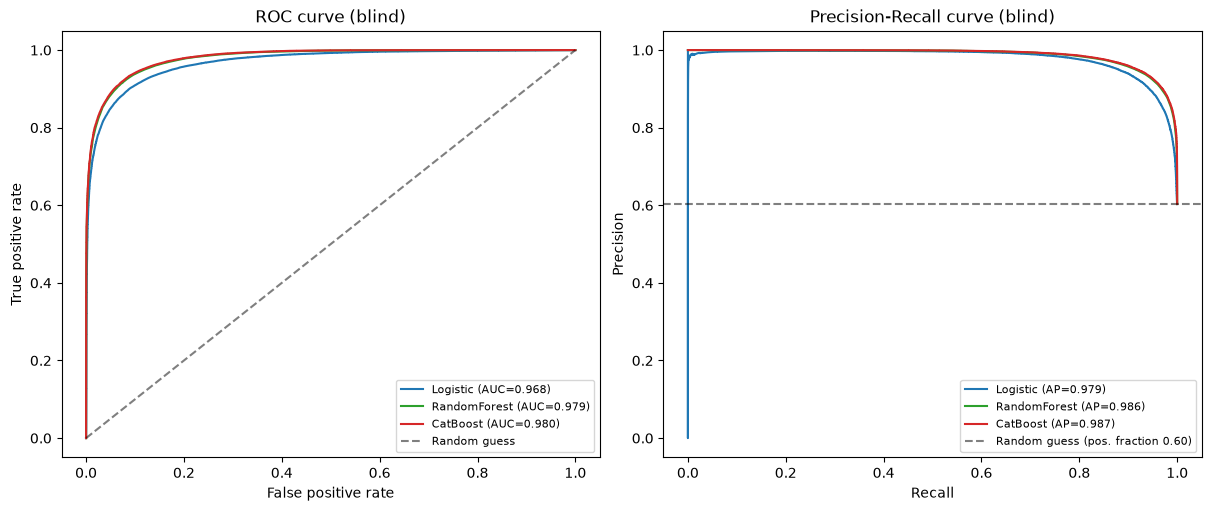

In [14]:
# 13. ROC 与 PR 曲线：三个分类器画在一起（用 blind 数据）
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
colors = {"Logistic": "tab:blue", "RandomForest": "tab:green", "CatBoost": "tab:red"}
bl_probs = {}

# —— 重新收集三个模型的 blind 概率（避免上面 cell 变量被覆盖）
# Logistic
lr_p = logreg.predict_proba(scaler.transform(Xbl_filled))[:, 1]
# RandomForest
rfc_p = rfc.predict_proba(Xbl_filled)[:, 1]
# CatBoost
cbc_p = cbc.predict_proba(Xbl)[:, 1]
bl_probs = {"Logistic": lr_p, "RandomForest": rfc_p, "CatBoost": cbc_p}

for name, p in bl_probs.items():
    fpr, tpr, _ = roc_curve(ybl_cls, p)
    axes[0].plot(fpr, tpr, color=colors[name],
                 label=f"{name} (AUC={roc_auc_score(ybl_cls, p):.3f})")
    prec, rec, _ = precision_recall_curve(ybl_cls, p)
    axes[1].plot(rec, prec, color=colors[name],
                 label=f"{name} (AP={average_precision_score(ybl_cls, p):.3f})")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random guess")
axes[0].set(xlabel="False positive rate", ylabel="True positive rate",
            title="ROC curve (blind)")
axes[0].legend(fontsize=8)
axes[1].axhline(pos_frac, color="k", ls="--", alpha=0.5,
                label=f"Random guess (pos. fraction {pos_frac:.2f})")
axes[1].set(xlabel="Recall", ylabel="Precision",
            title="Precision-Recall curve (blind)")
axes[1].legend(fontsize=8)
fig.savefig(OUT_DIR / "classification_curves.pdf")
plt.show()


### ROC vs PR：什么时候用哪个？

- **ROC-AUC**：与类别比例无关，适合"正负类比较平衡"或"两类都重要"。
- **PR-AUC**：对正类（我们关心恒星形成星系）更敏感。正类占比越接近 0，
  PR 曲线越能看出"少数的正类抓得准不准"。
- **accuracy**：最直观但最危险——不平衡时"全猜多数类"也能拿高分，
  第 8 格的 baseline 就是对照线。

第 13 格图上那条黑色虚线就是"随机猜"：任何模型在虚线上方才有价值。


In [15]:
# 14. 汇总分类成绩表 + 保存
# 注意：每个模型必须用自己的概率重新取阈值 0.5，不能混用别的模型的 yhat
summary = []
for name, p in [("Logistic", lr_p),
                ("RandomForest", rfc_p),
                ("CatBoost", cbc_p)]:
    yhat = (p > 0.5).astype(int)
    row = {"model": name}
    row.update(evaluate_classifier(ybl_cls, p, yhat))
    summary.append(row)

cls_table = pd.DataFrame(summary)
display(cls_table)
cls_table.to_csv(OUT_DIR / "classification_summary.csv", index=False)

print("\n结论检查：")
print("  1) accuracy 是否都超过 baseline %.1f%%？" % (pos_frac * 100))
print("  2) 三个模型的 ROC-AUC 差距大吗？谁最好？")
print("  3) 谁 train/blind 的 accuracy 差距最大（过拟合信号）？")


,model,accuracy,ROC-AUC,PR-AUC,TP,FP,FN,TN
0,Logistic,0.906185,0.967792,0.978543,62171,5273,5205,39039
1,RandomForest,0.921863,0.979066,0.985928,62361,3712,5015,40600
2,CatBoost,0.924835,0.980210,0.987029,63340,4359,4036,39953



结论检查：
  1) accuracy 是否都超过 baseline 60.3%？
  2) 三个模型的 ROC-AUC 差距大吗？谁最好？
  3) 谁 train/blind 的 accuracy 差距最大（过拟合信号）？


## Part 3：特征重要性——谁在驱动预测？

回归和分类各自学了不同的目标，**特征的重要性排序很可能不一样**。
对树模型可以直接读出重要性。这能回答一个物理问题：
*判断 SFR 高低，和判断"是否恒星形成"，靠的是同一组特征吗？*


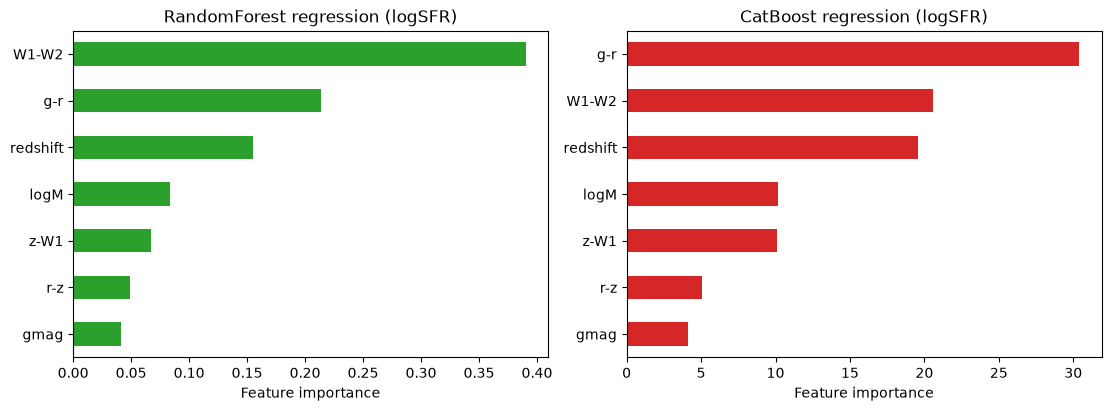

RandomForest 认为最重要: W1-W2   CatBoost 认为最重要: g-r

两个树模型的排序并不完全相同——特征重要性依赖具体模型。
但 logM / W1-W2 / g-r 都排在最前，物理上说得通：
logM 是主序先验，W1-W2 是恒星形成信号，g-r 是 SED 形状。


In [16]:
# 15. 特征重要性（RandomForest 回归 vs CatBoost 分类）
imp_rf = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
imp_cb = pd.Series(cb.get_feature_importance(), index=FEATURES).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
imp_rf.plot.barh(ax=axes[0], color="tab:green",
                 title="RandomForest regression (logSFR)")
imp_cb.plot.barh(ax=axes[1], color="tab:red",
                 title="CatBoost regression (logSFR)")
for ax in axes:
    ax.set_xlabel("Feature importance")
fig.savefig(OUT_DIR / "feature_importance_regression.pdf")
plt.show()

print("RandomForest 认为最重要:", imp_rf.idxmax(),
      "  CatBoost 认为最重要:", imp_cb.idxmax())
print("\n两个树模型的排序并不完全相同——特征重要性依赖具体模型。")
print("但 logM / W1-W2 / g-r 都排在最前，物理上说得通：")
print("logM 是主序先验，W1-W2 是恒星形成信号，g-r 是 SED 形状。")


## 总结：这个练手项目你带走了什么

| 概念 | 你亲手做过的事 |
|---|---|
| 回归模型对比 | 同一个任务跑 4 种模型，看 blind RMSE 分层 |
| 过拟合检测 | 每个模型都看 train/blind 两列，差距就是过拟合代价 |
| 预处理 | 线性/MLP 必须缩放和中位数填充，树模型不用 |
| 分类标签设计 | sSFR 单峰分布 → 阈值是物理约定，不是数据给的 |
| accuracy 陷阱 | 全猜多数类就是 60.3%，模型必须超过它 |
| ROC / PR | 阈值无关的排序指标 vs 正类敏感指标 |
| 类别不平衡 | class_weight='balanced' 的存在及其代价 |

下一步建议（任选）：
1. 把回归的 4 个模型预测画成残差直方图对比；
2. 换 `sSFR > -11` 再看分类，体会不平衡加剧后 PR-AUC 的变化；
3. 去 SciMLLab lesson 02 用 PyTorch 手写同一个 MLP。
